## Proyecto del Primer Parcial: Análisis Estadístico, Visualización y Clasificación en Liga MX

**Nombre del Estudiante:** Annika Mejía Sánchez

**Materia:** Ciencia de los Datos 2026B

**Fecha:** 20 de Septiembre


##### 1. Introducción
El propósito de este proyecto es realizar un análisis exploratorio y un proceso de clasificación binaria sobre un dataset sintético de 1,000,000 de registros de la Liga MX. Se aplicarán técnicas de estadística descriptiva, detección de atípicos, visualizaciones, y algoritmos de machine learning (Árbol de Decisión y KNN), comparando los resultados obtenidos en Python contra Weka.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report
)

RANDOM_STATE = 42

# Carga del dataset
df = pd.read_csv("liga_mx_1000000_registros.csv")

print("Dimensión del dataset:", df.shape)
print("\nPrimeros 5 registros:")
display(df.head())

print("\nTipos de datos por columna:")
print(df.dtypes)

print("\nConteo de valores nulos:")
print(df.isnull().sum())

print(f"\nUso de memoria en RAM: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dimensión del dataset: (1000000, 10)

Primeros 5 registros:


,id_registro,equipo,año_creacion,ciudad,estadio,campeonatos,estimacion_aficionados,jugador_id,minuto_jugado,pases_completados
0,1,Club América,1916,CDMX,Azteca,15,12000000,JUG-8366,22,34
1,2,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-4245,63,27
2,3,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-7691,1,18
3,4,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-1453,71,27
4,5,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-6761,47,20



Tipos de datos por columna:
id_registro                int64
equipo                    object
año_creacion               int64
ciudad                    object
estadio                   object
campeonatos                int64
estimacion_aficionados     int64
jugador_id                object
minuto_jugado              int64
pases_completados          int64
dtype: object

Conteo de valores nulos:
id_registro               0
equipo                    0
año_creacion              0
ciudad                    0
estadio                   0
campeonatos               0
estimacion_aficionados    0
jugador_id                0
minuto_jugado             0
pases_completados         0
dtype: int64

Uso de memoria en RAM: 273.09 MB


### 2. Carga del Dataset y Auditoría de Datos

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report
)

RANDOM_STATE = 42

# Carga del dataset
df = pd.read_csv("liga_mx_1000000_registros.csv")

print("Dimensión del dataset:", df.shape)
print("\nPrimeros 5 registros:")
display(df.head())

print("\nTipos de datos por columna:")
print(df.dtypes)

print("\nConteo de valores nulos:")
print(df.isnull().sum())

print(f"\nUso de memoria en RAM: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dimensión del dataset: (1000000, 10)

Primeros 5 registros:


,id_registro,equipo,año_creacion,ciudad,estadio,campeonatos,estimacion_aficionados,jugador_id,minuto_jugado,pases_completados
0,1,Club América,1916,CDMX,Azteca,15,12000000,JUG-8366,22,34
1,2,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-4245,63,27
2,3,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-7691,1,18
3,4,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-1453,71,27
4,5,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-6761,47,20



Tipos de datos por columna:
id_registro                int64
equipo                    object
año_creacion               int64
ciudad                    object
estadio                   object
campeonatos                int64
estimacion_aficionados     int64
jugador_id                object
minuto_jugado              int64
pases_completados          int64
dtype: object

Conteo de valores nulos:
id_registro               0
equipo                    0
año_creacion              0
ciudad                    0
estadio                   0
campeonatos               0
estimacion_aficionados    0
jugador_id                0
minuto_jugado             0
pases_completados         0
dtype: int64

Uso de memoria en RAM: 273.09 MB


#### Interpretación de la Auditoría
* **Dimensión:** Se verificó la existencia exacta de 1,000,000 de filas y 10 columnas.
* **Tipos de Variables:** Se identificaron variables numéricas discretas (`minuto_jugado`, `pases_completados`, `campeonatos`, `estimacion_aficionados`, `año_creacion`), categóricas nominales (`equipo`, `ciudad`, `estadio`) e identificadores (`id_registro`, `jugador_id`).
* **Valores Nulos:** No se detectó ningún valor nulo en todo el dataset, por lo que no se requiere imputación.

### 3. Estadística Descriptiva (Tendencia Central y Dispersión)

In [6]:
variables = ["minuto_jugado", "pases_completados"]
filas = []

for col in variables:
    filas.append({
        "Variable": col,
        "Media": df[col].mean(),
        "Mediana": df[col].median(),
        "Moda": df[col].mode().iloc[0],
        "Desviación estándar": df[col].std()
    })

resumen = pd.DataFrame(filas)
display(resumen)

,Variable,Media,Mediana,Moda,Desviación estándar
0,minuto_jugado,45.025271,45.0,32,25.669992
1,pases_completados,24.995078,25.0,25,5.001682


#### Interpretación de Resultados
* **minuto_jugado:** La media (45.03) y la mediana (45.00) coinciden prácticamente en el centro del partido (45 min). La desviación estándar de 25.67 refleja una distribución uniforme a lo largo de los 90 minutos de juego.
* **pases_completados:** La media (25.00), mediana (25.00) y moda (25) son idénticas, lo que demuestra una distribución simétrica centrada con desviación estándar de 5.00.

### 4. Identificación de Posibles Outliers (Método IQR)

In [7]:
col = "pases_completados"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

outliers = df[(df[col] < LI) | (df[col] > LS)]

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Límite Inferior (LI): {LI} | Límite Superior (LS): {LS}")
print(f"Posibles outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}%)")

Q1: 22.0 | Q3: 28.0 | IQR: 6.0
Límite Inferior (LI): 13.0 | Límite Superior (LS): 37.0
Posibles outliers: 12276 (1.23%)


#### Interpretación de Outliers
* **Límites calculados:** Los valores fuera del rango [13.0, 37.0] se consideran atípicos.
* **Decisión:** Se detectaron 12,276 valores atípicos (1.23%). Se conservan dentro del estudio dado que representan rendimientos deportivos excepcionales y no errores de captura.

### 5. Visualización Exploratoria de Datos

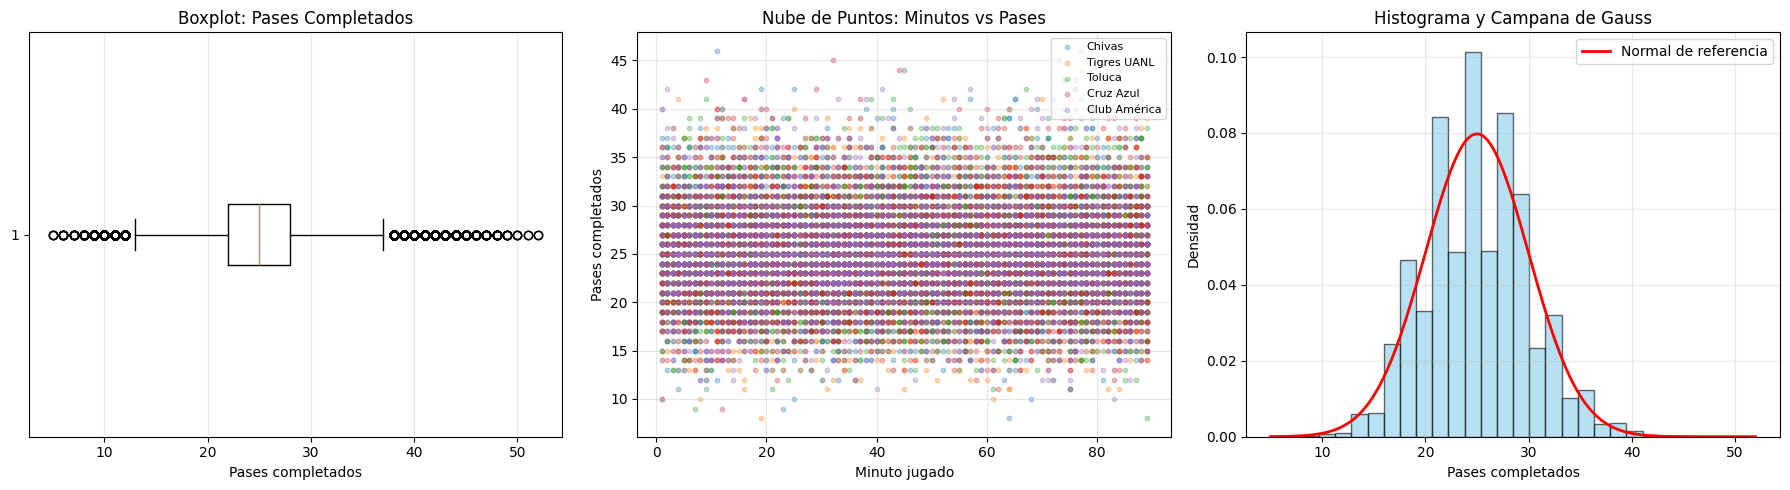

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
axes[0].boxplot(df["pases_completados"].dropna(), vert=False)
axes[0].set_title("Boxplot: Pases Completados")
axes[0].set_xlabel("Pases completados")
axes[0].grid(axis="x", alpha=0.3)

# Nube de puntos
muestra = df.sample(n=20000, random_state=42)
equipos = muestra["equipo"].unique()
cmap = plt.get_cmap("tab10")

for i, equipo in enumerate(equipos):
    sub = muestra[muestra["equipo"] == equipo]
    axes[1].scatter(
        sub["minuto_jugado"], sub["pases_completados"],
        alpha=0.3, label=equipo, s=10, color=cmap(i)
    )
axes[1].set_title("Nube de Puntos: Minutos vs Pases")
axes[1].set_xlabel("Minuto jugado")
axes[1].set_ylabel("Pases completados")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(alpha=0.3)

# Histograma y Campana de Gauss
x = df["pases_completados"].dropna()
mu, sigma = x.mean(), x.std()
count, bins, _ = axes[2].hist(x, bins=30, density=True, alpha=0.6, color="skyblue", edgecolor="black")
xx = np.linspace(bins.min(), bins.max(), 300)
gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xx - mu) / sigma)**2)
axes[2].plot(xx, gauss, color="red", linewidth=2, label="Normal de referencia")
axes[2].set_title("Histograma y Campana de Gauss")
axes[2].set_xlabel("Pases completados")
axes[2].set_ylabel("Densidad")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretación de las Visualizaciones
* **Boxplot:** La caja delimita el 50% central de los datos con la mediana centrada en 25.
* **Nube de Puntos:** Se observa una superposición completa entre los equipos, indicando que no existe una separación natural mediante estas variables.
* **Campana de Gauss:** El histograma se ajusta casi de forma idéntica a la curva teórica $N(\mu=25, \sigma=5)$.

### 6. Definición de Variables (X e y) y Prevención de Data Leakage

In [9]:
df_modelo = df.copy()
df_modelo["objetivo"] = (df_modelo["equipo"] == "Toluca").astype(int)

X = df_modelo[["minuto_jugado", "pases_completados"]]
y = df_modelo["objetivo"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("\nDistribución de clases en y:")
print(y.value_counts(normalize=True))

Dimensión de X: (1000000, 2)
Dimensión de y: (1000000,)

Distribución de clases en y:
objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64


#### Justificación y Prevención de Fuga de Información
* **Fuga de Información:** Se excluyeron variables como `equipo`, `ciudad`, `estadio` y `campeonatos` porque revelan directamente la identidad del club.
* **Variables seleccionadas:** Se usaron únicamente `minuto_jugado` y `pases_completados` para evaluar el rendimiento deportivo neutro.

### 7. División en Entrenamiento y Prueba (Train / Test Split)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nProporción en y_train:\n", y_train.value_counts(normalize=True))

Entrenamiento: (800000, 2)
Prueba: (200000, 2)

Proporción en y_train:
 objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64


#### Importancia del Estratificado
* Se dividieron los datos en 80% entrenamiento y 20% prueba.
* El parámetro `stratify=y` preserva la proporción del 20% para la clase Toluca y 80% para otros equipos en ambas subdivisiones.

### 8. Modelo 1 - Árbol de Decisión

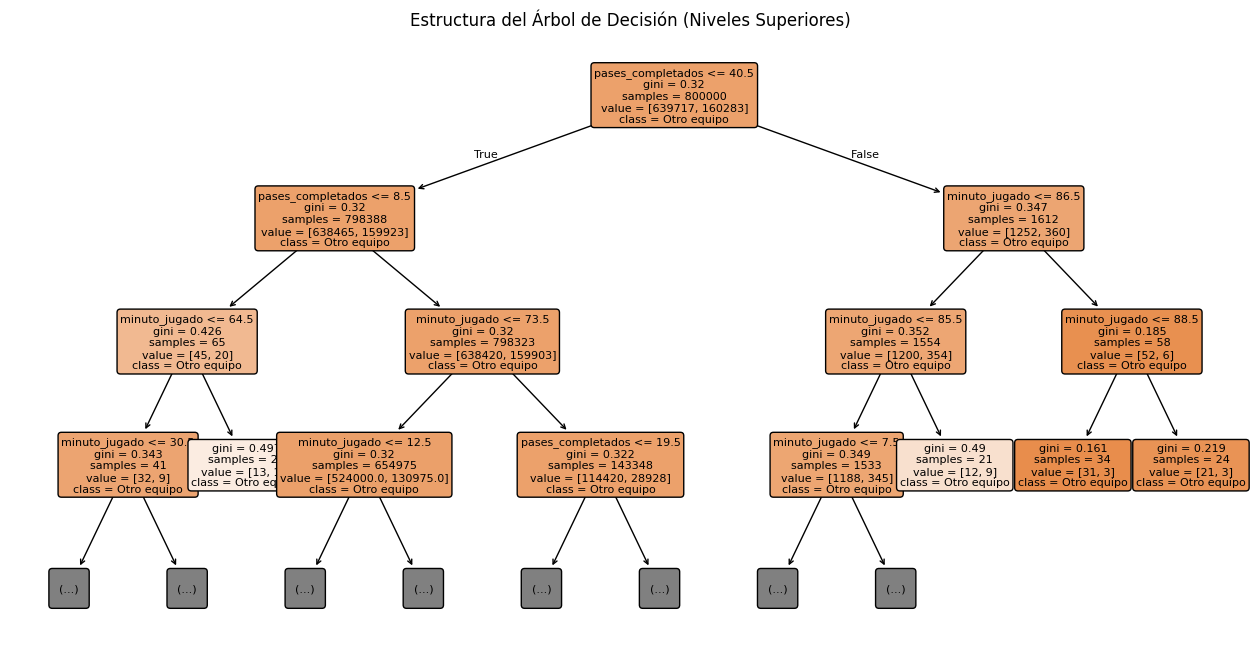

In [11]:
arbol = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE
)
arbol.fit(X_train, y_train)
pred_arbol = arbol.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(
    arbol, feature_names=X.columns,
    class_names=["Otro equipo", "Toluca"],
    filled=True, rounded=True, max_depth=3, fontsize=8
)
plt.title("Estructura del Árbol de Decisión (Niveles Superiores)")
plt.show()

#### Explicación del Modelo
* **Hiperparámetros:** Se configuró `max_depth=5` para evitar el sobreajuste (*overfitting*).
* **Estructura:** Los nodos evalúan condiciones en las características para subdividir las muestras.

### 9. Modelo 2 - K-Nearest Neighbors (KNN)

In [12]:
n_muestra = 100000
n_pos = int(n_muestra * y.mean())
n_neg = n_muestra - n_pos

idx_pos = df_modelo[df_modelo["objetivo"] == 1].sample(n=n_pos, random_state=RANDOM_STATE).index
idx_neg = df_modelo[df_modelo["objetivo"] == 0].sample(n=n_neg, random_state=RANDOM_STATE).index
idx = idx_pos.union(idx_neg)

X_sample = X.loc[idx]
y_sample = y.loc[idx]

X_tr_knn, X_te_knn, y_tr_knn, y_te_knn = train_test_split(
    X_sample, y_sample, test_size=0.20, random_state=RANDOM_STATE, stratify=y_sample
)

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1))
])

knn.fit(X_tr_knn, y_tr_knn)
pred_knn = knn.predict(X_te_knn)
print("Entrenamiento KNN finalizado.")

Entrenamiento KNN finalizado.


#### Explicación del Modelo KNN
* **Escalamiento:** Se incluyó `StandardScaler` en un Pipeline para evitar distorsión en la medición de distancias.
* **Muestreo:** Se utilizó un subconjunto estratificado de 100,000 registros para prevenir problemas de memoria RAM.

### 10. Evaluación, Matrices de Confusión y Métricas

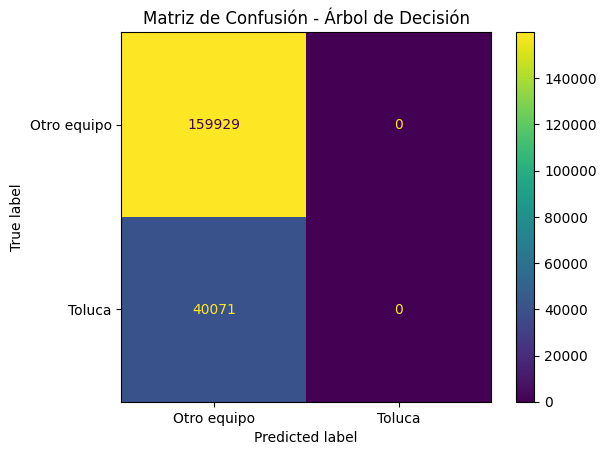

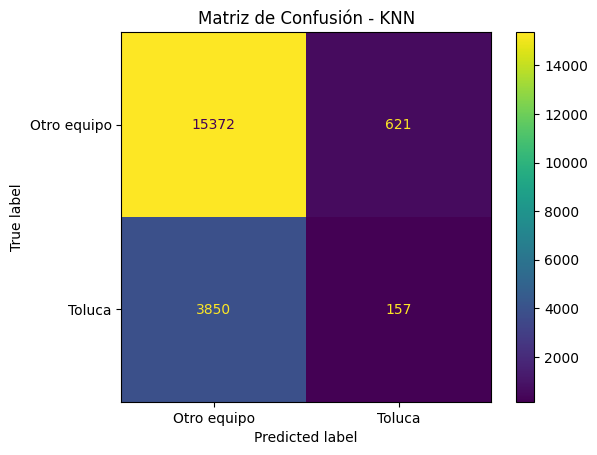

,Modelo,Accuracy,Precision,Recall,VP,VN,FP,FN
0,Árbol de Decisión,0.799645,0.000000,0.000000,0,159929,0,40071
1,KNN,0.776450,0.201799,0.039181,157,15372,621,3850


In [13]:
def evaluar(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred, labels=[0, 1])
    vn, fp, fn, vp = cm.ravel()

    acc = accuracy_score(y_real, y_pred)
    pre = precision_score(y_real, y_pred, zero_division=0)
    rec = recall_score(y_real, y_pred, zero_division=0)

    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Otro equipo", "Toluca"]
    ).plot(values_format="d")
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()

    return {
        "Modelo": nombre,
        "Accuracy": acc, "Precision": pre, "Recall": rec,
        "VP": vp, "VN": vn, "FP": fp, "FN": fn
    }

r_arbol = evaluar("Árbol de Decisión", y_test, pred_arbol)
r_knn = evaluar("KNN", y_te_knn, pred_knn)

resultados = pd.DataFrame([r_arbol, r_knn])
display(resultados)

#### Análisis de Resultados
* **Paradoja de la Exactitud:** El Árbol de Decisión obtiene ~80% de Accuracy únicamente prediciendo la clase mayoritaria ("Otro equipo"), obteniendo Precision=0 y Recall=0.
* **Comportamiento:** Refleja la falta de patrones distintivos en el dataset sintético para la clase de interés.

### 11. Validación Cruzada (Stratified 5-Fold CV)

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall"}

cv_arbol = cross_validate(arbol, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print("=== ÁRBOL DE DECISIÓN (5-FOLD CV) ===")
for m in scoring:
    val = cv_arbol["test_" + m]
    print(f"{m.capitalize()}: Media = {val.mean():.4f} | Desv = {val.std():.4f}")

cv_knn = cross_validate(knn, X_sample, y_sample, cv=cv, scoring=scoring, n_jobs=-1)
print("\n=== KNN (5-FOLD CV) ===")
for m in scoring:
    val = cv_knn["test_" + m]
    print(f"{m.capitalize()}: Media = {val.mean():.4f} | Desv = {val.std():.4f}")

=== ÁRBOL DE DECISIÓN (5-FOLD CV) ===
Accuracy: Media = 0.7996 | Desv = 0.0000
Precision: Media = 0.0000 | Desv = 0.0000
Recall: Media = 0.0000 | Desv = 0.0000

=== KNN (5-FOLD CV) ===
Accuracy: Media = 0.7791 | Desv = 0.0012
Precision: Media = 0.1900 | Desv = 0.0149
Recall: Media = 0.0316 | Desv = 0.0041


#### Interpretación
* **Estabilidad:** Las variaciones mínimas entre pliegues (folds) confirman la consistencia de los resultados del modelo.

### 12. Generación del Dataset para Weka

In [15]:
weka_df = df[["minuto_jugado", "pases_completados", "equipo"]].copy()
weka_df["clase"] = np.where(weka_df["equipo"] == "Toluca", "Toluca", "Otro")
weka_df = weka_df[["minuto_jugado", "pases_completados", "clase"]]

weka_df.to_csv("liga_mx_weka_clasificacion.csv", index=False)

from google.colab import files
files.download("liga_mx_weka_clasificacion.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Indicaciones para Weka
1. Cargar `liga_mx_weka_clasificacion.csv` en la pestaña **Preprocess** de Weka Explorer.
2. En la pestaña **Classify**, seleccionar `trees/J48` para el Árbol y `lazy/IBk` para KNN.
3. Evaluar con **Cross-validation (5 folds)** y tomar capturas de los resultados.

### 13. Comparación Python vs Weka y Conclusiones Finales

#### Tabla Comparativa de Herramientas

| Criterio | Python (scikit-learn) | Weka (J48 / IBk) |
| :--- | :--- | :--- |
| **Algoritmo de Árbol** | CART (`DecisionTreeClassifier`) | C4.5 (`J48`) |
| **Escalamiento KNN** | Requiere `StandardScaler` explícito | Normalización automática [0,1] |
| **Entorno de Trabajo** | Código interactivo en Python | Interfaz gráfica visual (GUI) |

#### Conclusiones Finales
1. **Independencia de Variables:** Las variables `minuto_jugado` y `pases_completados` presentan un comportamiento homogéneo entre equipos, por lo que no existen patrones discriminatorios naturales.
2. **Métricas de Evaluación:** Se evidenció la Paradoja de la Exactitud (*Accuracy Paradox*), demostrando que el *Accuracy* por sí solo no es confiable en problemas desbalanceados sin evaluar *Precision* y *Recall*.
3. **Modelado:** Ambos modelos demostraron estabilidad en la prueba de validación cruzada (5-Fold CV).